Dataset Shape: (168, 2)

First 5 Records:


,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        168 non-null    datetime64[ns]
 1   Production  168 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.8 KB

Missing Values:
Date          0
Production    0
dtype: int64

Summary Statistics:


,Date,Production
count,168,168.000000
mean,1968-12-15 16:17:08.571428572,754.708333
min,1962-01-01 00:00:00,553.000000
25%,1965-06-23 12:00:00,677.750000
50%,1968-12-16 12:00:00,761.000000
75%,1972-06-08 12:00:00,824.500000
max,1975-12-01 00:00:00,969.000000
std,NaN,102.204524


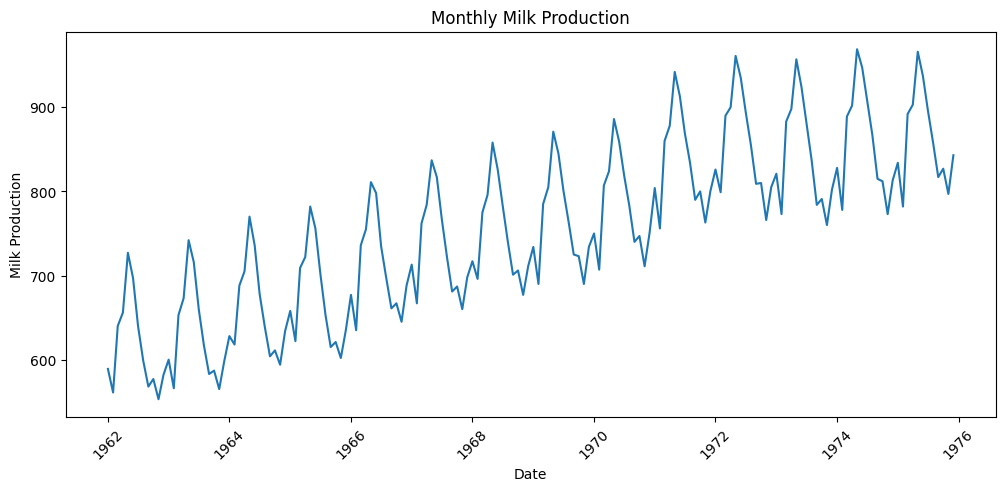

In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("/content/monthly_milk_production.csv")

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"])

# Sort by date
df = df.sort_values("Date")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Records:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

# Plot monthly production
plt.figure(figsize=(12, 5))

plt.plot(
    df["Date"],
    df["Production"]
)

plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.xticks(rotation=45)

plt.show()

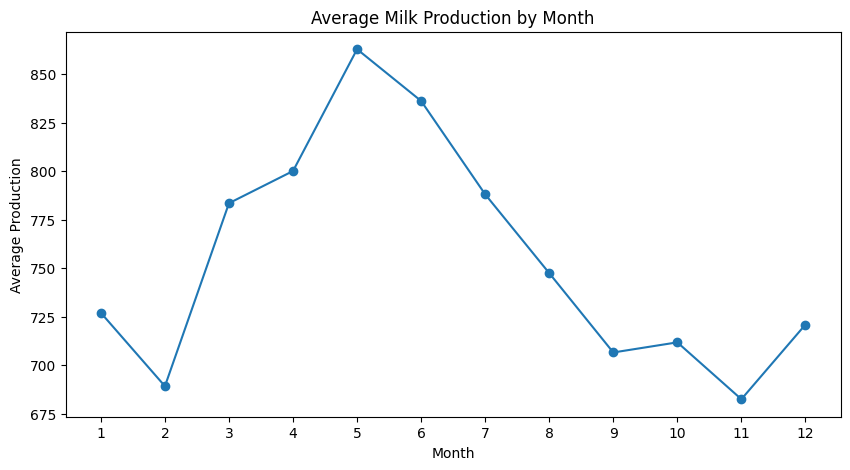

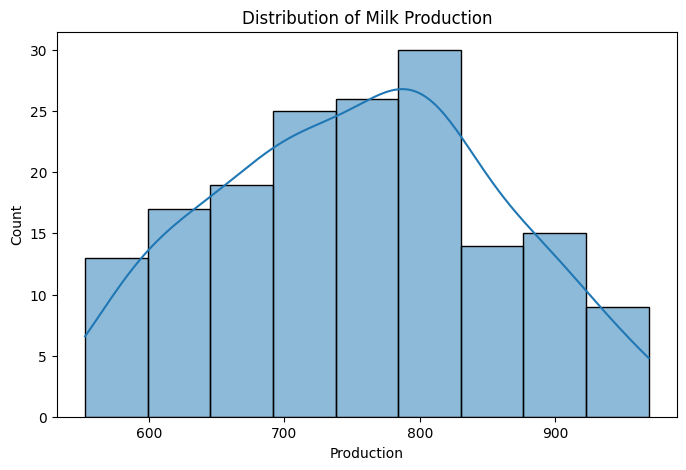

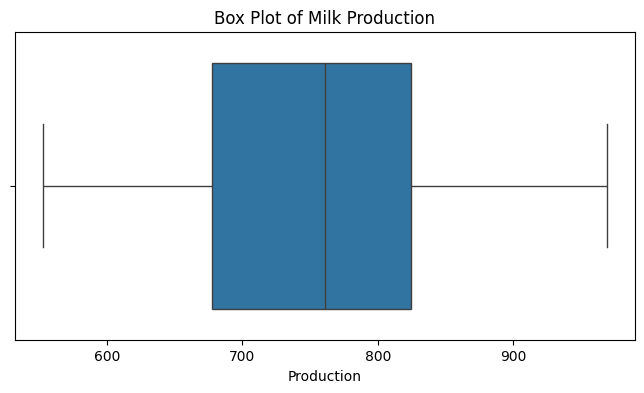

In [102]:
# Create month column
df["Month"] = df["Date"].dt.month

# Monthly average production
monthly_avg = df.groupby("Month")["Production"].mean()

# Monthly seasonality plot
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Average Milk Production by Month")
plt.xlabel("Month")
plt.ylabel("Average Production")
plt.xticks(range(1, 13))

plt.show()


# Distribution of production
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Production"],
    kde=True
)

plt.title("Distribution of Milk Production")
plt.xlabel("Production")

plt.show()


# Box plot
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["Production"]
)

plt.title("Box Plot of Milk Production")

plt.show()

In [103]:
from sklearn.preprocessing import MinMaxScaler

# Use only production values
values = df["Production"].values.reshape(-1, 1)

# Scale production values
scaler = MinMaxScaler()

scaled_values = scaler.fit_transform(values)

# Window size
window_size = 12

X = []
y = []

for i in range(window_size, len(scaled_values)):

    X.append(
        scaled_values[i-window_size:i, 0]
    )

    y.append(
        scaled_values[i, 0]
    )

X = np.array(X)
y = np.array(y)

# Reshape for RNN/LSTM/GRU
X = X.reshape(
    X.shape[0],
    X.shape[1],
    1
)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# Chronological split
train_size = int(len(X) * 0.70)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print("\nTraining samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Testing samples:", len(X_test))

X Shape: (156, 12, 1)
y Shape: (156,)

Training samples: 109
Validation samples: 23
Testing samples: 24


In [104]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Function to create RNN model
def create_rnn():

    model = Sequential([
        SimpleRNN(
            64,
            input_shape=(window_size, 1)
        ),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model


# Function to create LSTM model
def create_lstm():

    model = Sequential([
        LSTM(
            64,
            input_shape=(window_size, 1)
        ),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model


# Function to create GRU model
def create_gru():

    model = Sequential([
        GRU(
            64,
            input_shape=(window_size, 1)
        ),
        Dropout(0.2),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model


# Create models
rnn_model = create_rnn()
lstm_model = create_lstm()
gru_model = create_gru()

# Early stopping
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

print("RNN Model:")
rnn_model.summary()

print("\nLSTM Model:")
lstm_model.summary()

print("\nGRU Model:")
gru_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


RNN Model:


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,289 (16.75 KB)

...

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
# Train RNN
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)


# Train LSTM
lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)


# Train GRU
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=16,
    callbacks=[early_stop],
    verbose=0
)

print("RNN, LSTM and GRU training completed.")

RNN, LSTM and GRU training completed.


In [106]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Predictions
rnn_pred = rnn_model.predict(X_test, verbose=0)
lstm_pred = lstm_model.predict(X_test, verbose=0)
gru_pred = gru_model.predict(X_test, verbose=0)


# Convert predictions back to original scale
y_test_actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
).flatten()

rnn_pred_actual = scaler.inverse_transform(
    rnn_pred
).flatten()

lstm_pred_actual = scaler.inverse_transform(
    lstm_pred
).flatten()

gru_pred_actual = scaler.inverse_transform(
    gru_pred
).flatten()


# Evaluation function
def evaluate_model(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

    return mae, rmse, mape


# Evaluate all models
rnn_scores = evaluate_model(
    y_test_actual,
    rnn_pred_actual
)

lstm_scores = evaluate_model(
    y_test_actual,
    lstm_pred_actual
)

gru_scores = evaluate_model(
    y_test_actual,
    gru_pred_actual
)


# Results table
results = pd.DataFrame({
    "Model": [
        "RNN",
        "LSTM",
        "GRU"
    ],

    "MAE": [
        rnn_scores[0],
        lstm_scores[0],
        gru_scores[0]
    ],

    "RMSE": [
        rnn_scores[1],
        lstm_scores[1],
        gru_scores[1]
    ],

    "MAPE (%)": [
        rnn_scores[2],
        lstm_scores[2],
        gru_scores[2]
    ]
})

display(results.round(2))

,Model,MAE,RMSE,MAPE (%)
0,RNN,13.22,14.98,1.53
1,LSTM,111.37,127.32,12.52
2,GRU,126.76,139.76,14.36


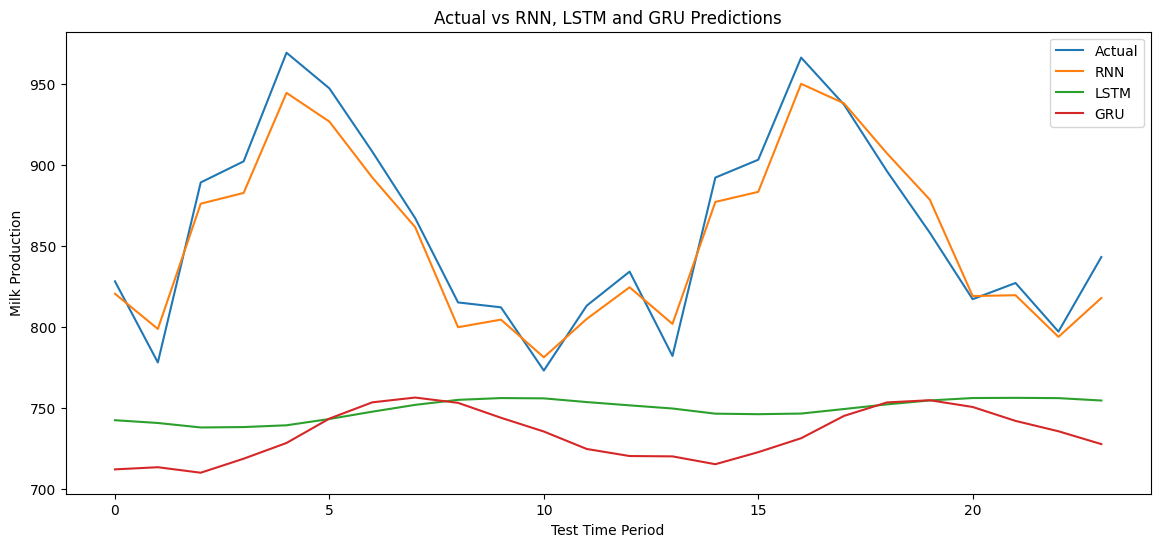

In [107]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test_actual,
    label="Actual"
)

plt.plot(
    rnn_pred_actual,
    label="RNN"
)

plt.plot(
    lstm_pred_actual,
    label="LSTM"
)

plt.plot(
    gru_pred_actual,
    label="GRU"
)

plt.title(
    "Actual vs RNN, LSTM and GRU Predictions"
)

plt.xlabel("Test Time Period")
plt.ylabel("Milk Production")

plt.legend()

plt.show()

# 12-Month Forecast and Business Insights

The best-performing model based on the lowest RMSE is selected for forecasting
the next 12 months.

### Business Insights

The forecast can help the dairy business:

- Plan milk collection and storage capacity.
- Manage workforce requirements.
- Prepare transportation and distribution.
- Plan inventory and supply chain activities.
- Anticipate seasonal changes in production.
- Make better production and resource allocation decisions.

### Conclusion

RNN, LSTM, and GRU models were successfully developed for monthly milk
production forecasting.

The models were evaluated using MAE, RMSE, and MAPE.

The model with the lowest RMSE is selected as the best model for future
forecasting.

Deep learning time-series models can capture sequential patterns in milk
production and can therefore be useful for production planning and
decision-making.

Best Model based on RMSE: RNN

Next 12 Months Forecast:


,Date,Forecasted Production
0,1976-01-01,834.030029
1,1976-02-01,806.609985
2,1976-03-01,877.849976
3,1976-04-01,885.159973
4,1976-05-01,942.599976
5,1976-06-01,925.250000
6,1976-07-01,900.429993
7,1976-08-01,872.559998
8,1976-09-01,826.849976
9,1976-10-01,835.219971


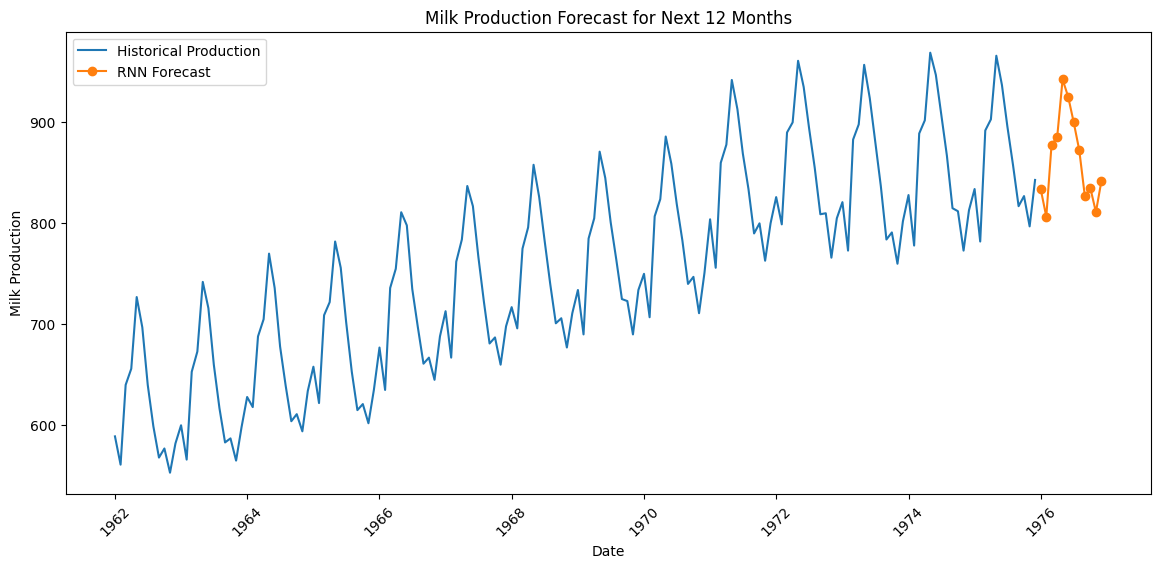

In [108]:
# Select best model based on RMSE
rmse_values = {
    "RNN": rnn_scores[1],
    "LSTM": lstm_scores[1],
    "GRU": gru_scores[1]
}

best_model_name = min(
    rmse_values,
    key=rmse_values.get
)

print(
    "Best Model based on RMSE:",
    best_model_name
)


# Select best model
models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model
}

best_model = models[best_model_name]


# Last 12 months
last_sequence = scaled_values[-window_size:].copy()

future_predictions = []

for i in range(12):

    # Reshape for model
    current_input = last_sequence.reshape(
        1,
        window_size,
        1
    )

    # Predict next month
    next_prediction = best_model.predict(
        current_input,
        verbose=0
    )[0, 0]

    future_predictions.append(
        next_prediction
    )

    # Add prediction to sequence
    last_sequence = np.append(
        last_sequence[1:],
        next_prediction
    )


# Convert back to original production scale
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
).flatten()


# Future dates
last_date = df["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)


# Forecast table
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecasted Production": future_predictions
})

print("\nNext 12 Months Forecast:")
display(forecast_df.round(2))


# Plot historical + forecast
plt.figure(figsize=(14, 6))

plt.plot(
    df["Date"],
    df["Production"],
    label="Historical Production"
)

plt.plot(
    future_dates,
    future_predictions,
    marker="o",
    label=f"{best_model_name} Forecast"
)

plt.title(
    "Milk Production Forecast for Next 12 Months"
)

plt.xlabel("Date")
plt.ylabel("Milk Production")

plt.legend()

plt.xticks(rotation=45)

plt.show()